In [1]:
from pathlib import Path
import json
import pandas as pd
import plotly.express as px

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    while True:
        # repo markers that always exist
        if (cur / "src").exists() and ((cur / "README.md").exists() or (cur / "requirements.txt").exists()):
            return cur
        if cur == cur.parent:
            break
        cur = cur.parent
    raise RuntimeError("Cannot locate repo root (expected 'src/' + README/requirements).")

REPO_ROOT = find_repo_root(Path.cwd())
OUT_DIR = REPO_ROOT / "artifacts" / "reports" / "feature_importance"

print("REPO_ROOT:", REPO_ROOT)
print("OUT_DIR  :", OUT_DIR)

csvs = sorted(OUT_DIR.glob("*.csv")) if OUT_DIR.exists() else []
if not csvs:
    raise RuntimeError(
        f"No feature importance CSV found under {OUT_DIR}.\n"
        f"Run from repo root:\n"
        f"  python -m src.train --model voting_mean\n"
        f"  python analysis/feature_importance.py\n"
    )

# pick newest by modified time
csvs = sorted(csvs, key=lambda p: p.stat().st_mtime, reverse=True)
CSV_PATH = csvs[0]

# more robust meta discovery:
# 1) same stem but .json
# 2) fallback: replace '__top' -> '__meta' if applicable
META_PATH = CSV_PATH.with_suffix(".json")
if not META_PATH.exists():
    META_PATH = CSV_PATH.with_name(CSV_PATH.name.replace("__top", "__meta").replace(".csv", ".json"))

print("Selected CSV :", CSV_PATH.name)
print("Selected META:", META_PATH.name if META_PATH.exists() else "(missing)")

df = pd.read_csv(CSV_PATH)
df.head(20)



REPO_ROOT: C:\Users\23517\OneDrive\Documents\GitHub\house-prices-ml-pipeline
OUT_DIR  : C:\Users\23517\OneDrive\Documents\GitHub\house-prices-ml-pipeline\artifacts\reports\feature_importance
Selected CSV : voting_mean__2026-01-18_002048__top30.csv
Selected META: (missing)


,feature,importance,abs_importance
0,LotArea,2498.252205,2498.252205
1,LotFrontage,1691.755337,1691.755337
2,BsmtUnfSF,1507.751524,1507.751524
3,GrLivArea,1505.255127,1505.255127
4,TotalSF,1436.507255,1436.507255
5,QualTotalSF,1396.814913,1396.814913
6,TotalPorchSF,1290.752380,1290.752380
7,QualGarage,1261.765937,1261.765937
8,TotalBsmtSF,1234.004913,1234.004913
9,MoSold,1189.751276,1189.751276


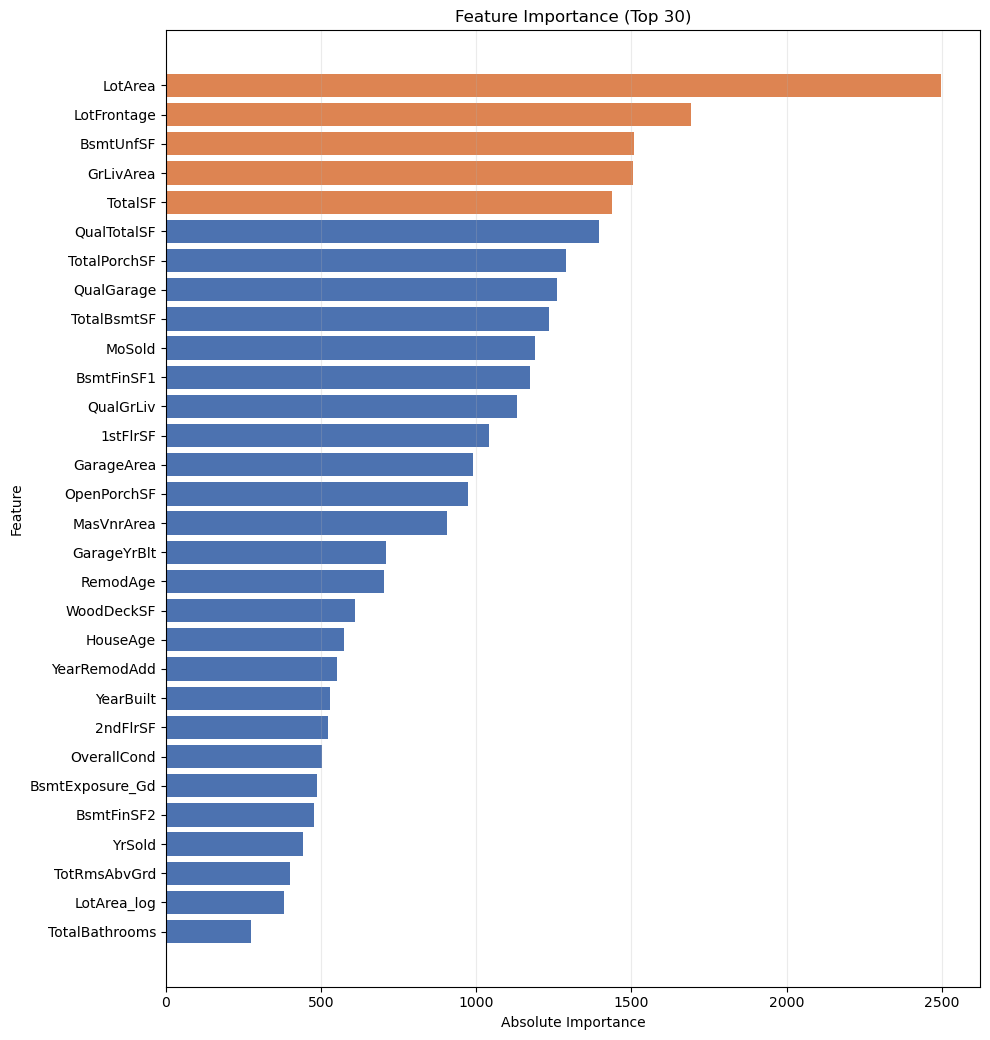

,feature,importance,abs_importance
0,LotArea,2498.252205,2498.252205
1,LotFrontage,1691.755337,1691.755337
2,BsmtUnfSF,1507.751524,1507.751524
3,GrLivArea,1505.255127,1505.255127
4,TotalSF,1436.507255,1436.507255
5,QualTotalSF,1396.814913,1396.814913
6,TotalPorchSF,1290.752380,1290.752380
7,QualGarage,1261.765937,1261.765937
8,TotalBsmtSF,1234.004913,1234.004913
9,MoSold,1189.751276,1189.751276


In [3]:
import matplotlib.pyplot as plt
import json

topk = 30

show = df.head(topk).iloc[::-1]

# -------- title --------
title = f"Feature Importance (Top {topk})"
if META_PATH.exists():
    meta = json.loads(META_PATH.read_text(encoding="utf-8"))
    model = meta.get("model", "")
    run_id = meta.get("run_id", "")
    title = f"Feature Importance (Top {topk}) — {model}  run={run_id}"

# -------- plot --------
plt.figure(figsize=(10, max(6, 0.35 * topk)))
plt.barh(show["feature"], show["abs_importance"], color="#4C72B0", alpha=0.85)
plt.barh(
    show["feature"],
    show["abs_importance"],
    color=["#DD8452" if i >= topk-5 else "#4C72B0" for i in range(topk)],
)
plt.title(title)
plt.xlabel("Absolute Importance")
plt.ylabel("Feature")

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# -------- table preview --------
df.head(topk)


Feature Importance Analysis (Global Best Model)

The feature importance results highlight that the model’s predictions are primarily driven by property size, location-related frontage, and overall quality signals, which is consistent with economic intuition in housing markets.

Among all features, LotFrontage emerges as the most influential variable by a clear margin, suggesting that street exposure and lot positioning play a critical role in determining sale price beyond total lot size alone. GrLivArea and TotalSF-related features (such as QualTotalSF) follow closely, confirming that usable living area is one of the strongest determinants of housing value.

Quality-adjusted features, including QualGarage, QualGrLiv, and overall condition indicators, rank higher than their raw counterparts. This indicates that the model benefits from engineered features that combine size with quality information, allowing it to better differentiate homes with similar square footage but different build or finish standards.

Temporal and depreciation-related variables such as HouseAge, RemodAge, and YearBuilt also contribute meaningfully, reflecting the market’s sensitivity to property age and renovation history. In contrast, room counts and bathroom totals appear lower in importance, likely because their effects are already captured implicitly through size and quality composite features.

Overall, the importance ranking suggests that the model relies on structural fundamentals and quality-adjusted measures rather than sparse categorical effects, supporting the robustness and generalizability of the selected global best model.